# Importing Packages #

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import cv2
import tensorflow as tf
from keras.models import Sequential, load_model, Model
from keras import regularizers
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, SimpleRNN, Reshape
from keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from skimage import io, color, transform

# Loading Dataset #

The dataset used here is the Facial Emotion Recognition (FER2013) dataset. This dataset consists of 48 x 48 grayscale images of faces. Each face is put into a sub directory belonging to an emotion. It can be downloaded at: https://www.kaggle.com/datasets/msambare/fer2013

We took two approaches to this model. One was straight image analysis and the other was by using Action Units (AUs). In order to extract AUs, we had one of our members run OpenFace on the dataset and then pass this dataset containing the AUs to another member for processing.

This dataset does have a neutral subset that was filtered out as we are not looking at this emotion.

In [2]:
cols = [' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
        ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
        ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
        ' AU26_r', ' AU45_r', ' AU01_c', ' AU02_c', ' AU04_c',
        ' AU05_c', ' AU06_c', ' AU07_c', ' AU09_c', ' AU10_c',
        ' AU12_c', ' AU14_c', ' AU15_c', ' AU17_c', ' AU20_c',
        ' AU23_c', ' AU25_c', ' AU26_c', ' AU28_c', ' AU45_c',
        'filename', 'emotion', 'dataset']

df = pd.read_csv("resources/fer2013_complete.csv", usecols=cols)

labels = {'happy': 0, 'sad': 1, 'angry': 2, 'fear': 3, 'disgust': 4, 'surprise': 5}

train_data = df[df['dataset'] == 'train']
test_data = df[df['dataset'] == 'test']

In [3]:
folder = r"C:\Users\Keanu\Downloads\fer2013\train" # Change to FER2013 training set path

train_images = []

for filename, emotion in zip(train_data['filename'], train_data['emotion']):
    label = os.path.join(folder, emotion)
    filepath = os.path.join(label, filename)
    if filepath.endswith('.jpg'):
        image = io.imread(filepath, as_gray=True)
        image_resized = transform.resize(image, (48, 48))
        image_reshaped = np.expand_dims(image_resized, axis=-1)
        train_images.append(image_reshaped)

X_train = np.array(train_images)
y_train = to_categorical(train_data['emotion'].map(labels), num_classes = 6)

folder = r"C:\Users\Keanu\Downloads\fer2013\test" # Change to FER2013 test set path

test_images = []

for filename, emotion in zip(test_data['filename'], test_data['emotion']):
    label = os.path.join(folder, emotion)
    filepath = os.path.join(label, filename)
    if filepath.endswith('.jpg'):
        image = io.imread(filepath, as_gray=True)
        image_resized = transform.resize(image, (48, 48))
        image_reshaped = np.expand_dims(image_resized, axis=-1)
        test_images.append(image_reshaped)

X_test = np.array(test_images)
y_test = to_categorical(test_data['emotion'].map(labels), num_classes = 6)

# Image to Emotion Model #

This model does not utilize the AUs, but rather performs direct image analysis on the faces instead. This mdoel was chosen as the model for the system. In the section for the AU mode, there is an explanation why we chose this model instead.

Epoch 1/30
110/110 [==============================] - 2s 15ms/step - loss: 1.7341 - accuracy: 0.2759 - val_loss: 1.6825 - val_accuracy: 0.2778
Epoch 2/30
110/110 [==============================] - 1s 11ms/step - loss: 1.6742 - accuracy: 0.2914 - val_loss: 1.6474 - val_accuracy: 0.2985
Epoch 3/30
110/110 [==============================] - 1s 11ms/step - loss: 1.5807 - accuracy: 0.3480 - val_loss: 1.4556 - val_accuracy: 0.3934
Epoch 4/30
110/110 [==============================] - 1s 11ms/step - loss: 1.4456 - accuracy: 0.4299 - val_loss: 1.3954 - val_accuracy: 0.4405
Epoch 5/30
110/110 [==============================] - 1s 13ms/step - loss: 1.3976 - accuracy: 0.4563 - val_loss: 1.3212 - val_accuracy: 0.4646
Epoch 6/30
110/110 [==============================] - 1s 11ms/step - loss: 1.3518 - accuracy: 0.4713 - val_loss: 1.2919 - val_accuracy: 0.4725
Epoch 7/30
110/110 [==============================] - 1s 12ms/step - loss: 1.3011 - accuracy: 0.4879 - val_loss: 1.2619 - val_accuracy: 0.4787

<AxesSubplot:>

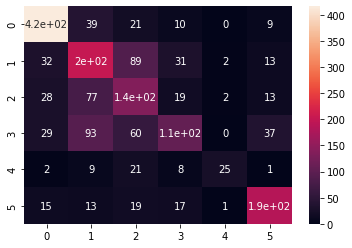

In [77]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    Dropout(0.5),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    Dropout(0.5),
    Conv2D(256, kernel_size=(3, 3), activation='relu'),
    Dropout(0.5),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.7),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=64, verbose=1, validation_data=(X_test, y_test))

# pred = np.argmax(model(X), axis=1)

# predict
y_pred = model.predict(X_test)

# get max of data
y_pred_true = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_true))

# confusion matrix
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_true, y_pred_true)
sns.heatmap(conf_matrix, annot=True)

In [8]:
model.save("model_image.keras")

# Action Unit to Emotion Model #

This model on the other hand, does utilize the AUs that were generated from OpenFace. 

We did not choose to use this model in the end due to a few factors. One was that the complexity of the program would increase needing to integrate OpenFace to grab AUs and another was that the model performed worse than the image model. While we recognize our data may not be the best set to train AUs on, this model could probably perform better with more time and data.

Epoch 1/60
220/220 [==============================] - 4s 8ms/step - loss: 1.9866 - accuracy: 0.3766 - val_loss: 1.3502 - val_accuracy: 0.4652
Epoch 2/60
220/220 [==============================] - 1s 6ms/step - loss: 1.5600 - accuracy: 0.4183 - val_loss: 1.3055 - val_accuracy: 0.4669
Epoch 3/60
220/220 [==============================] - 1s 7ms/step - loss: 1.4209 - accuracy: 0.4405 - val_loss: 1.2880 - val_accuracy: 0.4815
Epoch 4/60
220/220 [==============================] - 2s 7ms/step - loss: 1.3482 - accuracy: 0.4565 - val_loss: 1.2873 - val_accuracy: 0.4753
Epoch 5/60
220/220 [==============================] - 1s 7ms/step - loss: 1.3014 - accuracy: 0.4700 - val_loss: 1.2729 - val_accuracy: 0.4809
Epoch 6/60
220/220 [==============================] - 2s 7ms/step - loss: 1.3090 - accuracy: 0.4732 - val_loss: 1.2624 - val_accuracy: 0.4888
Epoch 7/60
220/220 [==============================] - 2s 7ms/step - loss: 1.2951 - accuracy: 0.4811 - val_loss: 1.2729 - val_accuracy: 0.4759
Epoch 

<Axes: >

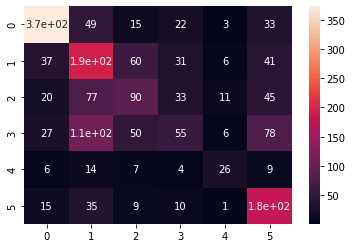

In [4]:
X_train = train_data[[' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
                      ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
                      ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
                      ' AU26_r', ' AU45_r']].values
y_train = to_categorical(train_data['emotion'].map(labels), num_classes = 6)

X_test = test_data[[' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
                    ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
                    ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
                    ' AU26_r', ' AU45_r']].values

y_test = to_categorical(test_data['emotion'].map(labels), num_classes = 6)

model = Sequential([
    Dense(32, activation='relu', input_shape=(17,)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=60, batch_size=32, verbose=1, validation_data=(X_test, y_test))

# pred = np.argmax(model(X), axis=1)

# predict
y_pred = model.predict(X_test)

# get max of data
y_pred_true = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_true))

# confusion matrix
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_true, y_pred_true)
sns.heatmap(conf_matrix, annot=True)

# Emotion to AU (Attempt 1) #

This was the first attempt in trying to grab the output AUs from the emotion. However, this attempt proved to not work that well.

Epoch 1/20
220/220 [==============================] - 2s 6ms/step - loss: 48.6416 - accuracy: 0.1666 - val_loss: 46.9610 - val_accuracy: 0.1717
Epoch 2/20
220/220 [==============================] - 1s 4ms/step - loss: 45.5816 - accuracy: 0.1732 - val_loss: 46.9610 - val_accuracy: 0.1717
Epoch 3/20
220/220 [==============================] - 1s 4ms/step - loss: 45.5816 - accuracy: 0.1732 - val_loss: 46.9610 - val_accuracy: 0.1717
Epoch 4/20
220/220 [==============================] - 1s 4ms/step - loss: 45.5816 - accuracy: 0.1732 - val_loss: 46.9610 - val_accuracy: 0.1717
Epoch 5/20
220/220 [==============================] - 1s 4ms/step - loss: 45.5816 - accuracy: 0.1732 - val_loss: 46.9610 - val_accuracy: 0.1717
Epoch 6/20
220/220 [==============================] - 1s 4ms/step - loss: 45.5816 - accuracy: 0.1732 - val_loss: 46.9610 - val_accuracy: 0.1717
Epoch 7/20
220/220 [==============================] - 1s 4ms/step - loss: 45.5816 - accuracy: 0.1732 - val_loss: 46.9610 - val_accuracy:

<Axes: >

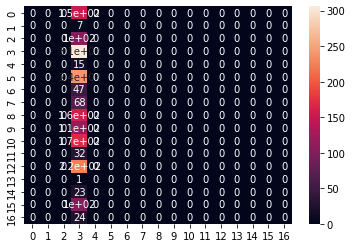

In [8]:
X_train = to_categorical(train_data['emotion'].map(labels), num_classes=6)
y_train = train_data[[' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
                      ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
                      ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
                      ' AU26_r', ' AU45_r']].values

X_test = to_categorical(test_data['emotion'].map(labels), num_classes=6)
y_test = test_data[[' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
                    ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
                    ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
                    ' AU26_r', ' AU45_r']].values

input_layer = Input(shape=(6,))
hidden_layer1 = Dense(32, activation='relu')(input_layer)
hidden_layer2 = Dense(64, activation='relu')(hidden_layer1)
hidden_layer3 = Dense(128, activation='relu')(hidden_layer2)
hidden_layer4 = Dense(256, activation='relu')(hidden_layer3)
hidden_layer5 = Dense(512, activation='relu')(hidden_layer4)
output_layer = Dense(17, activation='linear')(hidden_layer5)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1, validation_data=(X_test, y_test))

# Predict
y_pred = model.predict(X_test)

# pred = np.argmax(model(X), axis=1)

# predict
y_pred = model.predict(X_test)

# get max of data
y_pred_true = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_true, zero_division=0))

# confusion matrix
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_true, y_pred_true)
sns.heatmap(conf_matrix, annot=True)

# Emotion to AU (Attempt 2) #

Second attempt in trying to grab the output AUs from the emotion. We decided to take a more random approach to doing this. In this case, we did not have a method of testing how well it works as we did not have a virtual avatar to display these AU intensities. This was more out of scope here and trying to just explore methods into outputting facial AUs.

In [10]:
# @title attempt 2
X_train_emotions = to_categorical(train_data['emotion'].map(labels), num_classes=6)
X_train_presence = np.array(train_data[[' AU01_c', ' AU02_c', ' AU04_c',
                                        ' AU05_c', ' AU06_c', ' AU07_c',
                                        ' AU09_c', ' AU10_c', ' AU12_c',
                                        ' AU14_c', ' AU15_c', ' AU17_c',
                                        ' AU20_c', ' AU23_c', ' AU25_c',
                                        ' AU26_c', ' AU28_c', ' AU45_c',]])
X_train = np.concatenate((X_train_emotions, X_train_presence), axis=1)
y_train = train_data[[' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
                      ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
                      ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
                      ' AU26_r', ' AU45_r']].values

X_test_emotions = to_categorical(test_data['emotion'].map(labels), num_classes=6)
X_test_presence = np.array(test_data[[' AU01_c', ' AU02_c', ' AU04_c',
                                      ' AU05_c', ' AU06_c', ' AU07_c',
                                      ' AU09_c', ' AU10_c', ' AU12_c',
                                      ' AU14_c', ' AU15_c', ' AU17_c',
                                      ' AU20_c', ' AU23_c', ' AU25_c',
                                      ' AU26_c', ' AU28_c', ' AU45_c',]])
X_test = np.concatenate((X_train_emotions, X_train_presence), axis=1)
y_test = test_data[[' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
                    ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
                    ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
                    ' AU26_r', ' AU45_r']].values

input_layer = Input(shape=(24,))
hidden_layer1 = Dense(32, activation='relu')(input_layer)
hidden_layer2 = Dense(64, activation='relu')(hidden_layer1)
hidden_layer3 = Dense(128, activation='relu')(hidden_layer2)
hidden_layer4 = Dense(256, activation='relu')(hidden_layer3)
hidden_layer5 = Dense(512, activation='relu')(hidden_layer4)
output_layer = Dense(17, activation='linear')(hidden_layer5)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1)

y_pred = model.predict(X_test)

Epoch 1/20
110/110 [==============================] - 1s 4ms/step - loss: 0.2624 - accuracy: 0.3160
Epoch 2/20
110/110 [==============================] - 0s 3ms/step - loss: 0.2188 - accuracy: 0.3776
Epoch 3/20
110/110 [==============================] - 0s 3ms/step - loss: 0.2069 - accuracy: 0.3856
Epoch 4/20
110/110 [==============================] - 0s 3ms/step - loss: 0.2006 - accuracy: 0.3995
Epoch 5/20
110/110 [==============================] - 0s 3ms/step - loss: 0.1943 - accuracy: 0.4085
Epoch 6/20
110/110 [==============================] - 0s 3ms/step - loss: 0.1908 - accuracy: 0.4138
Epoch 7/20
110/110 [==============================] - 0s 3ms/step - loss: 0.1877 - accuracy: 0.4158
Epoch 8/20
110/110 [==============================] - 0s 3ms/step - loss: 0.1851 - accuracy: 0.4207
Epoch 9/20
110/110 [==============================] - 0s 3ms/step - loss: 0.1803 - accuracy: 0.4299
Epoch 10/20
110/110 [==============================] - 0s 3ms/step - loss: 0.1772 - accuracy: 0.4336

In [11]:
# @title attempt 2 category loading
au_presences = df[[' AU01_c', ' AU02_c', ' AU04_c', ' AU05_c', ' AU06_c',
                   ' AU07_c', ' AU09_c', ' AU10_c', ' AU12_c', ' AU14_c',
                   ' AU15_c', ' AU17_c', ' AU20_c', ' AU23_c', ' AU25_c',
                   ' AU26_c', ' AU28_c', ' AU45_c', 'emotion']]

angry_au = au_presences[au_presences['emotion'] == 'angry'].drop(columns=['emotion'])
disgust_au = au_presences[au_presences['emotion'] == 'disgust'].drop(columns=['emotion'])
fear_au = au_presences[au_presences['emotion'] == 'fear'].drop(columns=['emotion'])
happy_au = au_presences[au_presences['emotion'] == 'happy'].drop(columns=['emotion'])
sad_au = au_presences[au_presences['emotion'] == 'sad'].drop(columns=['emotion'])
surprise_au = au_presences[au_presences['emotion'] == 'surprise'].drop(columns=['emotion'])

angry_au_proportion = (angry_au == 1).mean()
disgust_au_proportion = (disgust_au == 1).mean()
fear_au_proportion = (fear_au == 1).mean()
happy_au_proportion = (happy_au == 1).mean()
sad_au_proportion = (sad_au == 1).mean()
surprise_au_proportion = (surprise_au == 1).mean()

au_proportions = [happy_au_proportion, sad_au_proportion, angry_au_proportion, fear_au_proportion, disgust_au_proportion , surprise_au_proportion]

emotion = 'sad' # output emotion here

au_proportion = au_proportions[labels[emotion]]

au_series = au_proportion.apply(lambda p: np.random.choice([0, 1], p=[1-p, p]))

emo_cat = np.zeros(6)
emo_cat[labels[emotion]] = 1

au_array = np.array(au_series)

x = np.concatenate((emo_cat, au_array)).reshape(1,24)

y = model(x)

In [12]:
print(y)

tf.Tensor(
[[ 0.18893781  0.04484781  0.30976018  0.07873584  0.4607728   0.80662155
   0.48738858  0.07264858  0.09194142 -0.16157205  0.19358683  0.04089041
   0.873089    0.04500898  0.11054557  0.18420133  0.04792891]], shape=(1, 17), dtype=float32)


Here, we output a csv from the model of au_proportions to load for the main program

In [13]:
# Convert the list of Series to a DataFrame
au_proportions_df = pd.concat(au_proportions, axis=1)

# Assign column names
au_proportions_df.columns = ['happy', 'sad', 'angry', 'fear', 'disgust' , 'surprise']

# Save the DataFrame to a CSV file
au_proportions_df.to_csv('au_proportions.csv', index=False)

In [14]:
emotion = 'sad' # output emotion here

au_proportion = au_proportions[labels[emotion]]

au_series = au_proportion.apply(lambda p: np.random.choice([0, 1], p=[1-p, p]))

emo_cat = np.zeros(6)
emo_cat[labels[emotion]] = 1

au_array = np.array(au_series)

x = np.concatenate((emo_cat, au_array)).reshape(1,24)

y = model(x)

In [15]:
print(y)

tf.Tensor(
[[ 0.65752727  0.251295   -0.02487152  0.4536481   0.19187456  0.04303479
  -0.04264812  0.1522508   0.639012    1.062417    0.04191935  0.17797993
   0.907966    0.2694258   0.23784803 -0.00558195 -0.01397594]], shape=(1, 17), dtype=float32)


In [16]:
model.save("model_AU.keras")

# Extra Test Case #
Here we can use this code to test a video on the image model. You just need to modify the path fed into the cv2.VideoCapture function

In [ ]:
model_image = load_model("resources/model_image.keras")

In [15]:
vid = cv2.VideoCapture('output.avi')
# Get the total number of frames in the video
total_frames = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))
# Calculate the number of frames per second
fps = int(vid.get(cv2.CAP_PROP_FPS))
# Calculate the total number of seconds
total_seconds = total_frames // fps

# Array to hold the first frame of every second
frames_every_second = []
# For each second in the video
for i in range(total_seconds):
    # Set the video position to the first frame of the current second
    vid.set(cv2.CAP_PROP_POS_FRAMES, i * fps)
    # Read the frame
    ret, frame = vid.read()
    if ret:
        # Crop the frame to 48x48 around the center
        y, x = frame.shape[0:2]
        start_x = x//2-(48//2)
        start_y = y//2-(48//2)
        cropped_frame = frame[start_y:start_y+48, start_x:start_x+48]
        # Add the cropped frame to the array
        frames_every_second.append(cropped_frame)

frames_every_second = [cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) for frame in frames_every_second]

# Normalize the pixel values
frames_every_second = [frame / 255.0 for frame in frames_every_second]

# Expand the dimensions of the frames
frames_every_second = [np.expand_dims(frame, axis=2) for frame in frames_every_second]

# Convert the list to a numpy array
frames_every_second = np.array(frames_every_second)

# Now you can feed the frames into your model
predictions = model_image(frames_every_second)